# Conjunction Example

Swarm A        39452          G13            24876          2024-05-10 23:57:00    5.27           91.9360        46.3219        84.3357        47.1436        
Swarm A        39452          G22            26407          2024-05-10 14:24:00    2.40           215.7932       59.6434        219.3534       61.2761        
Swarm A        39452          G17            28874          2024-05-10 14:23:00    6.91           200.9753       31.6523        201.6451       38.5454        
Swarm A        39452          G15            32260          2024-05-10 00:26:00    8.50           108.0991       59.5353        118.2135       53.1283        
Swarm A        39452          G18            44506          2024-05-09 00:56:00    2.81           165.1563       36.2485        164.9658       33.4416        

Swarm A        39452          G13            24876          2024-05-10 23:57:00    4.63           77.8338        48.7353        84.3258        47.1422        
Swarm A        39452          G21            27704          2024-05-09 13:19:00    9.15           119.1573       40.8740        115.8690       32.1118        
Swarm B        39451          G22            26407          2024-05-09 16:20:00    8.89           142.8371       35.1577        153.7325       35.8339        
Swarm B        39451          G25            36585          2024-05-09 17:53:00    9.27           303.0537       42.2128        292.5650       37.5984        
Swarm B        39451          G03            40294          2024-05-09 06:41:00    9.15           231.8120       40.0788        232.6185       49.2079        
Swarm C        39453          G13            24876          2024-05-10 23:57:00    4.04           85.3080        51.1322        84.3258        47.1422        
Swarm C        39453          G22            26407          2024-05-10 14:24:00    9.50           218.4052       51.7834        219.3810       61.2690

Swarm A        39452          G13            24876          2024-05-07 00:18:00    1.56           82.7886        47.8800        81.4750        46.6024        
Swarm A        39452          G13            24876          2024-05-10 23:57:00    4.63           77.8338        48.7353        84.3258        47.1422        
Swarm A        39452          G13            24876          2024-05-14 23:35:00    5.43           79.9552        48.1581        88.0054        47.5966        
Swarm A        39452          G22            26407          2024-05-06 14:45:00    8.91           210.4956       53.6578        215.2885       62.1988        
Swarm A        39452          G21            27704          2024-05-01 03:11:00    7.90           292.2490       32.5151        296.0294       39.8000        
Swarm A        39452          G21            27704          2024-05-02 02:42:00    7.96           300.7799       39.6014        305.0807       32.4389        
Swarm A        39452          G21            27704          2024-05-05 13:40:00    9.15           112.0566       42.7176        114.1204       33.7134        
Swarm A        39452          G21            27704          2024-05-09 13:19:00    9.15           119.1573       40.8740        115.8690       32.1118        
Swarm A        39452          G17            28874          2024-05-02 15:06:00    5.12           203.2025       38.7526        199.7388       43.1579        
Swarm A        39452          G30            39533          2024-05-07 23:48:00    6.86           35.4914        35.0252        41.2452        30.1605        
Swarm A        39452          G30            39533          2024-05-11 23:27:00    9.15           34.0243        34.7557        43.3200        30.0355        
Swarm A        39452          G24            38833          2024-05-08 15:23:00    6.03           292.9907       44.9366        287.6324       40.3676        
Swarm A        39452          G24            38833          2024-05-11 15:30:00    9.72           285.7615       34.7321        276.4435       41.1116        
Swarm A        39452          G24            38833          2024-05-12 15:01:00    6.37           285.6809       44.7747        290.7898       39.6492        
Swarm A        39452          G08            40730          2024-05-01 14:02:00    8.49           80.1941        46.0787        76.5252        38.0388        
Swarm A        39452          G08            40730          2024-05-13 12:58:00    8.80           69.2482        45.0167        81.1882        43.0471        
Swarm A        39452          G10            41019          2024-05-03 02:14:00    8.30           245.8780       53.2580        233.0925       57.2779        
Swarm A        39452          G18            44506          2024-05-05 01:17:00    9.51           164.0591       40.9150        164.5450       31.4163 

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cdflib
import datetime as dt
import pymap3d as pm
from scipy.signal import welch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from gnss_scintillation import parse, analyze, utils

# Update rcParams for larger fonts  
mpl.rcParams.update({  
    "font.size": 12,           # Base font size  
    "axes.titlesize": 16,      # Title font size  
    "axes.labelsize": 14,      # Axis label font size  
    "xtick.labelsize": 12,     # X-tick font size  
    "ytick.labelsize": 12,     # Y-tick font size  
    "legend.fontsize": 12,     # Legend font size  
    "font.family": "sans-serif",  # Use sans-serif fonts (cleaner for plots)  
    "font.sans-serif": ["Arial", "DejaVu Sans"]  # Fallback fonts  
})  


In [2]:
#swarm_filename = 'SW_EXTD_EFIA_LP_FP_20240510T001849_20240510T192423_0203.cdf'
# swarm_filename = 'SW_EXTD_EFIA_LP_FP_20170916T001138_20170916T232648_0203.cdf'
swarm_filename = 'SW_EXTD_EFIB_LP_FP_20170918T000000_20170918T235958_0201.cdf'
# gnss_filename = '170916_140000.nvd.gz'
gnss_filename = '170918_080000.nvd.gz'
# gnss_filename = '170528_080000.nvd.gz'
# starttime = np.datetime64('2017-04-19T04:30:00')
# endtime = np.datetime64('2017-04-19T04:45:00')
# starttime = np.datetime64('2017-09-16T14:00:00')
# endtime = np.datetime64('2017-09-16T15:00:00')
starttime = np.datetime64('2017-09-18T08:00:00')
endtime = np.datetime64('2017-09-18T09:00:00')
# starttime = np.datetime64('2017-05-28T08:00:00')
# endtime = np.datetime64('2017-05-28T09:00:00')
zoom_lim = [np.datetime64('2017-09-18T08:05:00'), np.datetime64('2017-09-18T08:10:00')]
prn = 3
# prn = 11
receiver_site = [56.53636, 280.768771, 0.]

In [3]:
# swarm_filename = 'SW_EXTD_EFIA_LP_FP_20240510T001849_20240510T192423_0203.cdf'

v = cdflib.CDF(swarm_filename)

swarm_time = cdflib.epochs.CDFepoch.to_datetime(v.varget('Timestamp'))
#swarm_utime = swarm_time.astype(int)

# Find indices for time range
stidx = np.argmin(np.abs(starttime-swarm_time))
etidx = np.argmin(np.abs(endtime-swarm_time))
# print(stidx, etidx)

swarm_time = swarm_time[stidx:etidx+1]
swarm_utime = swarm_time.astype('datetime64[s]').astype(int)
#swarm_utime = swarm_utime[stidx:etidx]

swarm_lat = v.varget('Latitude', startrec=stidx, endrec=etidx)
swarm_lon = v.varget('Longitude', startrec=stidx, endrec=etidx)
swarm_alt = v.varget('Height', startrec=stidx, endrec=etidx)*1000.
dens = v.varget('Density', startrec=stidx, endrec=etidx)

print(dens)

# # Quality flags
# qf = v.varget('Quality_flags', startrec=stidx, endrec=etidx)
# cf = v.varget('Calibration_flags', startrec=stidx, endrec=etidx)

# # Read velocities
# Vixh = v.varget('Vixh', startrec=stidx, endrec=etidx)
# Vixv = v.varget('Vixv', startrec=stidx, endrec=etidx)
# Viy = v.varget('Viy', startrec=stidx, endrec=etidx)
# Viz = v.varget('Viz', startrec=stidx, endrec=etidx)

[ 47381.484375    47381.48046875  48512.83984375 ... 124316.
 124315.9609375  124127.3515625 ]


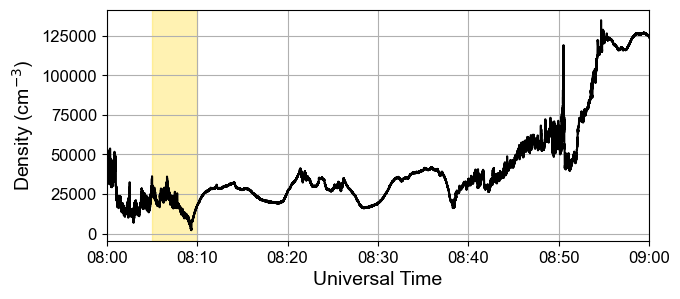

In [4]:
fig = plt.figure(figsize=(7,3))
ax = fig.add_subplot(111)
ax.plot(swarm_time, dens, color='black')
ax.set_xlim([starttime, endtime])
ax.axvspan(xmin=zoom_lim[0], xmax=zoom_lim[1], color='gold', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid()
ax.set_xlabel('Universal Time')
ax.set_ylabel('Density (cm$^{-3}$)')
# ax.set_ylim([0,7.e5])
plt.savefig('swarm_exmp.png')

In [5]:
# filename = '240510_140000.nvd.gz'
gnssdata = parse.ParseNovatel(gnss_filename)
time = utils.gps2utc(np.array(gnssdata.tstmp_wnc), (gnssdata.tstmp_tow))
pos_time = utils.gps2utc(np.array(gnssdata.tstmp_pos_wnc), (gnssdata.tstmp_pos_tow))
print(time)
# wnc, tow, phase, power = parse_novatel.read_file(filename)
# time = utils.gps2utc(wnc, tow)

['2017-09-18T08:00:18.000' '2017-09-18T08:00:18.020'
 '2017-09-18T08:00:18.040' ... '2017-09-18T09:00:17.940'
 '2017-09-18T09:00:17.960' '2017-09-18T09:00:17.980']


In [6]:
# gnss13 = parse.ParseNovatel('170916_130000.nvd.gz')
# gnss15 = parse.ParseNovatel('170916_150000.nvd.gz')
# gnss16 = parse.ParseNovatel('170916_160000.nvd.gz')
gnss06 = parse.ParseNovatel('170918_060000.nvd.gz')
gnss07 = parse.ParseNovatel('170918_070000.nvd.gz')
gnss09 = parse.ParseNovatel('170918_090000.nvd.gz')
# gnss10 = parse.ParseNovatel('170918_100000.nvd.gz')

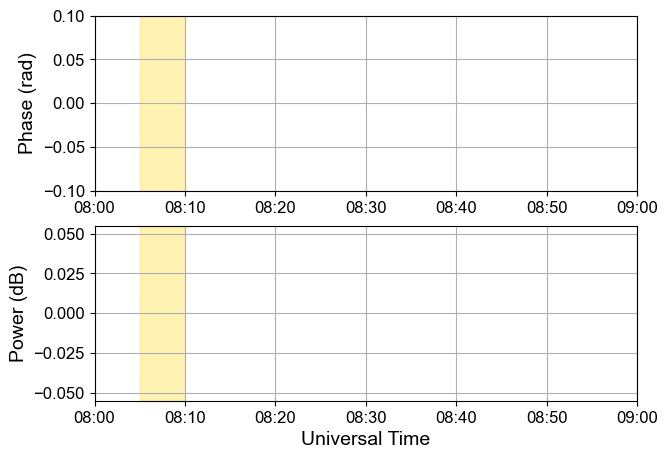

In [7]:
# pow0 = np.array(gnssdata.power[prn])
# phs0 = np.array(gnssdata.phase[prn])
# print(phs0)
# print(np.sum(np.isfinite(phs0)), len(phs0))

dt_pow = analyze.power_detrend(np.array(gnssdata.power[prn]))
dt_phs = analyze.phase_detrend(np.array(gnssdata.phase[prn]))
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(211)
ax.plot(time, dt_phs, linewidth=0.3, color='black')
ax.axvspan(xmin=zoom_lim[0], xmax=zoom_lim[1], color='gold', alpha=0.3)
ax.set_xlim([starttime, endtime])
ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylim([-0.1,0.1])
ax.set_ylabel('Phase (rad)')
ax = fig.add_subplot(212)
ax.plot(time, dt_pow, linewidth=0.3, color='black')
ax.axvspan(xmin=zoom_lim[0], xmax=zoom_lim[1], color='gold', alpha=0.3)
ax.set_xlim([starttime, endtime])
ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylabel('Power (dB)')
ax.set_xlabel('Universal Time')
plt.savefig('gnss_exmp.png')

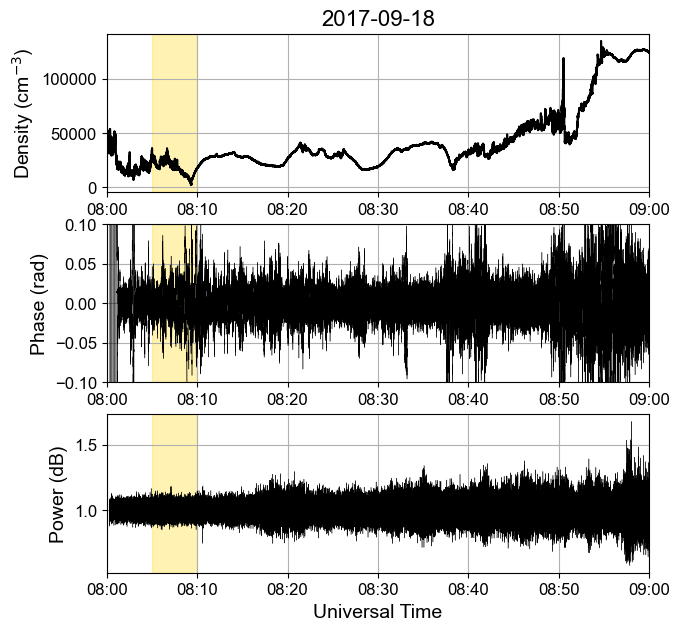

In [91]:
# Three pannel plot aligned for proposal

fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(311)
ax.plot(swarm_time, dens, color='black')
ax.set_xlim([starttime, endtime])
ax.axvspan(xmin=zoom_lim[0], xmax=zoom_lim[1], color='gold', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid()
# ax.set_xlabel('Universal Time')
ax.set_ylabel('Density (cm$^{-3}$)')
ax.set_title(np.datetime_as_string(swarm_time[0], unit='D'))
# ax.set_ylim([0,7.e5])
# plt.savefig('swarm_exmp.png')

# fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(312)
ax.plot(time, dt_phs, linewidth=0.3, color='black')
ax.axvspan(xmin=zoom_lim[0], xmax=zoom_lim[1], color='gold', alpha=0.3)
ax.set_xlim([starttime, endtime])
ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylim([-0.1,0.1])
ax.set_ylabel('Phase (rad)')

ax = fig.add_subplot(313)
ax.plot(time, dt_pow, linewidth=0.3, color='black')
ax.axvspan(xmin=zoom_lim[0], xmax=zoom_lim[1], color='gold', alpha=0.3)
ax.set_xlim([starttime, endtime])
ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylabel('Power (dB)')
ax.set_xlabel('Universal Time')
plt.savefig('three_panel_exmp.png')


['2017-09-18T08:05:00.031000000' '2017-09-18T08:06:00.031000000'
 '2017-09-18T08:07:00.031000000' '2017-09-18T08:08:00.031000000'
 '2017-09-18T08:09:00.031000000']


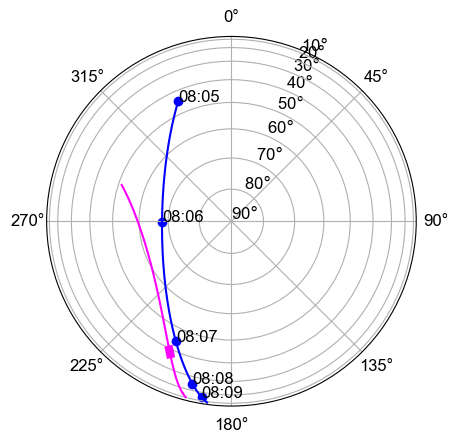

In [92]:
# stidx = np.argmin(np.abs(swarm_time-np.datetime64('2017-09-16T14:25:00')))
# etidx = np.argmin(np.abs(swarm_time-np.datetime64('2017-09-16T14:35:00')))
sw_stidx = np.argmin(np.abs(swarm_time-np.datetime64('2017-09-18T08:05:00')))+1
sw_etidx = np.argmin(np.abs(swarm_time-np.datetime64('2017-09-18T08:10:00')))
# print(sw_stidx, sw_etidx)
swaz, swel, _ = pm.geodetic2aer(swarm_lat, swarm_lon, swarm_alt, *receiver_site)
# swaz, swel, _ = pm.geodetic2aer(swarm_lat, swarm_lon, swarm_alt, *receiver_site)
# print(swaz, swel)

stidx = np.argmin(np.abs(pos_time-np.datetime64('2017-09-18T08:05:00')))
etidx = np.argmin(np.abs(pos_time-np.datetime64('2017-09-18T08:10:00')))
# print(stidx, etidx)

fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
el_ticks = np.arange(90., 0., -10.)
ax.set_ylim(0., 1.)
ax.set_yticks(np.cos(np.deg2rad(el_ticks)))
ax.set_yticklabels([rf'{el}$\degree$' for el in el_ticks.astype(int)])
ax.plot(np.deg2rad(gnssdata.azimuth[prn]), np.cos(np.deg2rad(gnssdata.elevation[prn])), color='magenta')
ax.plot(np.deg2rad(gnssdata.azimuth[prn])[stidx:etidx], np.cos(np.deg2rad(gnssdata.elevation[prn])[stidx:etidx]), color='magenta', linewidth=6)
# ax.plot(np.deg2rad(gnss13.azimuth[prn]), np.cos(np.deg2rad(gnss13.elevation[prn])), color='magenta')
# ax.plot(np.deg2rad(gnss15.azimuth[prn]), np.cos(np.deg2rad(gnss15.elevation[prn])), color='magenta')
# ax.plot(np.deg2rad(gnss16.azimuth[prn]), np.cos(np.deg2rad(gnss16.elevation[prn])), color='magenta')
ax.plot(np.deg2rad(gnss06.azimuth[prn]), np.cos(np.deg2rad(gnss06.elevation[prn])), color='magenta')
ax.plot(np.deg2rad(gnss07.azimuth[prn]), np.cos(np.deg2rad(gnss07.elevation[prn])), color='magenta')
ax.plot(np.deg2rad(gnss09.azimuth[prn]), np.cos(np.deg2rad(gnss09.elevation[prn])), color='magenta')
# ax.plot(np.deg2rad(gnss10.azimuth[prn]), np.cos(np.deg2rad(gnss10.elevation[prn])), color='magenta')
ax.plot(np.deg2rad(swaz[sw_stidx:sw_etidx]), np.cos(np.deg2rad(swel[sw_stidx:sw_etidx])), color='blue')
ax.scatter(np.deg2rad(swaz[sw_stidx:sw_etidx:960]), np.cos(np.deg2rad(swel[sw_stidx:sw_etidx:960])), color='blue')
print(swarm_time[sw_stidx:sw_etidx:960])
for az, el, tm in zip(swaz[sw_stidx:sw_etidx:960], swel[sw_stidx:sw_etidx:960], swarm_time[sw_stidx:sw_etidx:960]):
    ax.text(np.deg2rad(az), np.cos(np.deg2rad(el)), np.datetime_as_string(tm, unit='m')[11:])

plt.savefig('conj_polar.png')

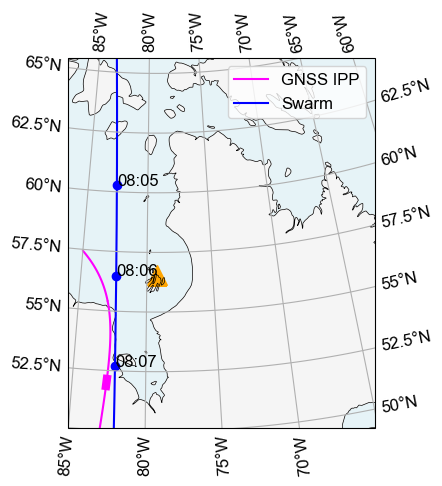

In [99]:
ipp_lat, ipp_lon = utils.calc_ipp(receiver_site, [gnssdata.azimuth[prn], gnssdata.elevation[prn]], height=500.)
# ipp_lat13, ipp_lon13 = utils.calc_ipp(receiver_site, [gnss13.azimuth[prn], gnss13.elevation[prn]], height=450.)
# ipp_lat15, ipp_lon15 = utils.calc_ipp(receiver_site, [gnss15.azimuth[prn], gnss15.elevation[prn]], height=450.)
# ipp_lat16, ipp_lon16 = utils.calc_ipp(receiver_site, [gnss16.azimuth[prn], gnss16.elevation[prn]], height=450.)
ipp_lat06, ipp_lon06 = utils.calc_ipp(receiver_site, [gnss06.azimuth[prn], gnss06.elevation[prn]], height=500.)
ipp_lat07, ipp_lon07 = utils.calc_ipp(receiver_site, [gnss07.azimuth[prn], gnss07.elevation[prn]], height=500.)
ipp_lat09, ipp_lon09 = utils.calc_ipp(receiver_site, [gnss09.azimuth[prn], gnss09.elevation[prn]], height=500.)
# ipp_lat10, ipp_lon10 = utils.calc_ipp(receiver_site, [gnss10.azimuth[prn], gnss10.elevation[prn]], height=450.)
# print(ipp_lat, ipp_lon)
map_proj = ccrs.AzimuthalEquidistant(central_longitude=receiver_site[1], central_latitude=receiver_site[0])
fig = plt.figure()
ax = fig.add_subplot(111, projection=map_proj)
ax.plot(ipp_lon, ipp_lat, color='magenta', label='GNSS IPP', transform=ccrs.Geodetic())
ax.plot(ipp_lon[stidx:etidx], ipp_lat[stidx:etidx], color='magenta', linewidth=6, transform=ccrs.Geodetic())
# ax.plot(ipp_lon13, ipp_lat13, color='magenta', transform=ccrs.Geodetic())
# ax.plot(ipp_lon15, ipp_lat15, color='magenta', transform=ccrs.Geodetic())
# ax.plot(ipp_lon16, ipp_lat16, color='magenta', transform=ccrs.Geodetic())
ax.plot(ipp_lon06, ipp_lat06, color='magenta', transform=ccrs.Geodetic())
ax.plot(ipp_lon07, ipp_lat07, color='magenta', transform=ccrs.Geodetic())
ax.plot(ipp_lon09, ipp_lat09, color='magenta', transform=ccrs.Geodetic())
# ax.plot(ipp_lon10, ipp_lat10, color='magenta', transform=ccrs.Geodetic())
ax.plot(swarm_lon, swarm_lat, color='blue', label='Swarm', transform=ccrs.Geodetic())
ax.scatter(swarm_lon[sw_stidx:sw_etidx:960], swarm_lat[sw_stidx:sw_etidx:960], color='blue', transform=ccrs.Geodetic())
for lat, lon, tm in zip(swarm_lat[sw_stidx:sw_etidx:960], swarm_lon[sw_stidx:sw_etidx:960], swarm_time[sw_stidx:sw_etidx:960]):
    ax.text(lon, lat, np.datetime_as_string(tm, unit='m')[11:], clip_on=True, clip_box=ax.bbox, transform=ccrs.Geodetic())
ax.scatter(receiver_site[1], receiver_site[0], s=200, color='orange', marker='^', transform=ccrs.Geodetic())
# ax.add_feature(cfeature.LAND)
# # ax.add_feature(cfeature.OCEAN)
# ax.coastlines()
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
ax.add_feature(cfeature.LAND, color='whitesmoke')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True)
ax.legend()
ax.set_extent([275.,295.,50.,65.])
plt.savefig('conj_map.png')

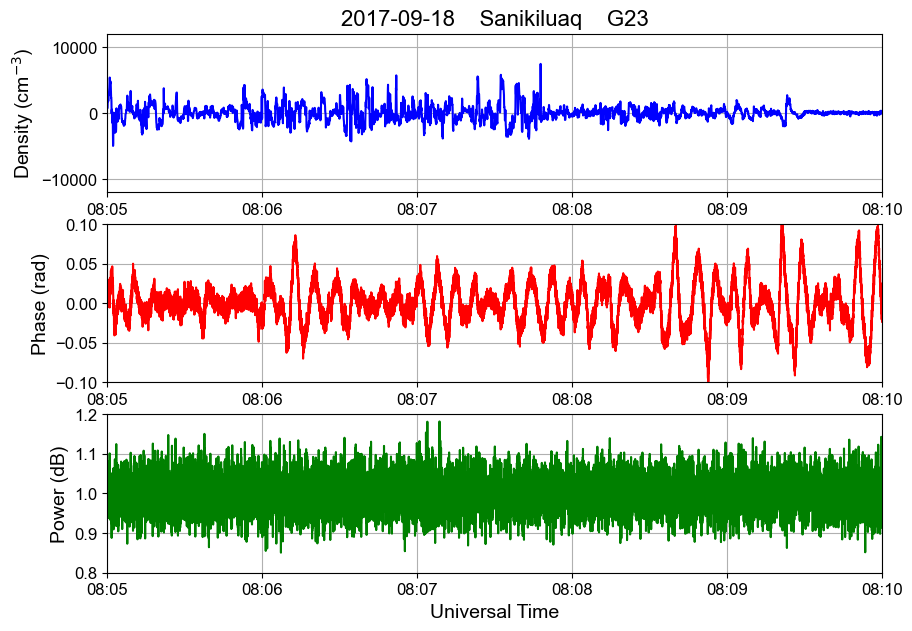

In [100]:
# plot_xlim = [np.datetime64('2017-09-16T14:25:00'), np.datetime64('2017-09-16T14:30:00')]
plot_xlim = [np.datetime64('2017-09-18T08:05:00'), np.datetime64('2017-09-18T08:10:00')]
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(311)
dt_dens = analyze.phase_detrend(dens, datarate=16.)
ax.plot(swarm_time, dt_dens, color='blue')
# ax.plot(swarm_time[stidx:etidx], dt_dens[stidx:etidx], color='red')
ax.set_xlim(plot_xlim)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid()
ax.set_ylim([-1.2e4,1.2e4])
ax.set_ylabel(r'Density (cm$^{-3}$)')
ax.set_title(f'{np.datetime_as_string(swarm_time[0], unit='D')}    Sanikiluaq    G{prn:02d}')
ax = fig.add_subplot(312)
ax.plot(time, dt_phs, color='red')
ax.set_xlim(plot_xlim)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid()
ax.set_ylim([-0.1,0.1])
ax.set_ylabel('Phase (rad)')
ax = fig.add_subplot(313)
ax.plot(time, dt_pow, color='green')
ax.set_xlim(plot_xlim)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid()
ax.set_ylim([0.8,1.2])
ax.set_ylabel('Power (dB)')
ax.set_xlabel('Universal Time')
fig.savefig('swarm_gnss_exmp.png')

[-1.736804   -2.30074654]
[-3.28523355 -2.77160551]
[-0.41336478 -4.00880842]


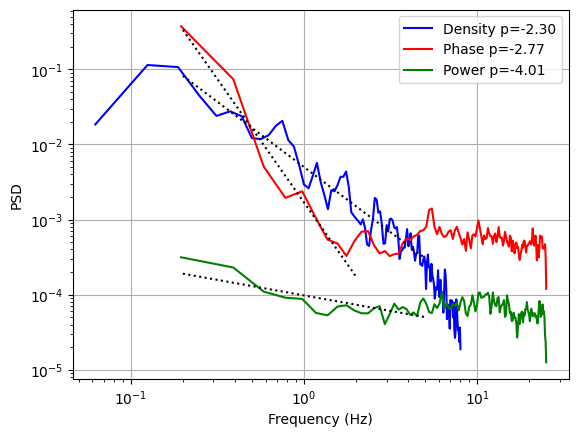

In [11]:
# stidx = np.argmin(np.abs(swarm_time-np.datetime64('2017-09-16T14:27:00')))
# etidx = np.argmin(np.abs(swarm_time-np.datetime64('2017-09-16T14:28:00')))
stidx = np.argmin(np.abs(swarm_time-np.datetime64('2017-09-18T08:07:00')))
etidx = np.argmin(np.abs(swarm_time-np.datetime64('2017-09-18T08:08:00')))
f_dens, Pxx_dens = welch(dt_dens[stidx:etidx]/10000., fs=16.)
# stidx = np.argmin(np.abs(time-np.datetime64('2017-09-16T14:27:00')))
# etidx = np.argmin(np.abs(time-np.datetime64('2017-09-16T14:28:00')))
stidx = np.argmin(np.abs(time-np.datetime64('2017-09-18T08:07:00')))
etidx = np.argmin(np.abs(time-np.datetime64('2017-09-18T08:08:00')))
f_phs, Pxx_phs = welch(dt_phs[stidx:etidx]/0.05, fs=50.)
# f_phs, Pxx_phs = welch(np.array(gnssdata.phase[prn]), fs=50.)
# fft = np.fft.fft(np.array(gnssdata.phase[prn]))
f_pow, Pxx_pow = welch(dt_pow[stidx:etidx], fs=50.)

# Line fitting
dens_fl = np.array([0.2, 5.])
lfidx = np.argmin(np.abs(dens_fl[0]-f_dens))
ufidx = np.argmin(np.abs(dens_fl[1]-f_dens))
dens_p = np.polyfit(np.log10(f_dens[lfidx:ufidx]), np.log10(Pxx_dens[lfidx:ufidx]), 1)
print(dens_p)
dens_pl = np.power(10, np.polyval(dens_p, np.log10(dens_fl)))

phs_fl = np.array([0.2, 2.])
lfidx = np.argmin(np.abs(phs_fl[0]-f_phs))
ufidx = np.argmin(np.abs(phs_fl[1]-f_phs))
phs_p = np.polyfit(np.log10(f_phs[lfidx:ufidx]), np.log10(Pxx_phs[lfidx:ufidx]), 1)
print(phs_p)
phs_pl = np.power(10, np.polyval(phs_p, np.log10(phs_fl)))

pow_fl = np.array([0.2, 5.])
lfidx = np.argmin(np.abs(pow_fl[0]-f_pow))
ufidx = np.argmin(np.abs(pow_fl[1]-f_pow))
pow_p = np.polyfit(np.log10(f_pow[lfidx:ufidx]), np.log10(Pxx_pow[lfidx:ufidx]), 1)
print(pow_p)
pow_pl = np.power(10, np.polyval(pow_p, np.log10(pow_fl)))

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(f_dens[1:], Pxx_dens[1:], color='blue', label=f'Density p={dens_p[1]:.2f}')
ax.plot(f_phs[1:], Pxx_phs[1:], color='red', label=f'Phase p={phs_p[1]:.2f}')
ax.plot(f_pow[1:], Pxx_pow[1:], color='green', label=f'Power p={pow_p[1]:.2f}')
ax.plot(dens_fl, dens_pl, linestyle=':', color='black')
ax.plot(phs_fl, phs_pl, linestyle=':', color='black')
ax.plot(pow_fl, pow_pl, linestyle=':', color='black')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid()
ax.legend()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
plt.savefig('spectra_exmp.png')

In [12]:
## Calculate CHAIN MLAT
import csv
from apexpy import Apex

apex = Apex(2024)
with open('CHAINsites.txt', 'r') as cf:
    chain_data = csv.reader(cf)
    for row in chain_data:
        # print(row)
        mlat, mlon = apex.geo2apex(float(row[2]), float(row[3]), height=0.)
        print(row[1], mlat, mlon)
        # if row[1] == receiver_name:
        #     receiver_site = [float(row[2]), float(row[3]), 0.]

arc 80.38822937011719 -11.044203758239746
arv 69.39448547363281 -24.596683502197266
cbb 75.83655548095703 -44.72243881225586
chu 67.21598052978516 -24.26544761657715
cor 72.32391357421875 -7.816236972808838
eur 86.61103820800781 -15.027480125427246
mcm 63.33891296386719 -48.150875091552734
fsi 66.5751724243164 -62.44655227661133
fsm 66.46612548828125 -50.13326644897461
gil 64.95125579833984 -24.7979736328125
gjo 76.20565795898438 -29.42616081237793
gri 83.41342163085938 -6.61715030670166
hal 76.45121765136719 -4.261801719665527
iqa 70.6424560546875 14.639554023742676
kug 73.3357162475586 -58.189605712890625
edm 59.856529235839844 -49.521385192871094
pon 79.86334991455078 2.249330520629883
qik 73.73492431640625 22.07257843017578
rab 65.89373779296875 -38.313514709472656
ran 71.07159423828125 -21.801721572875977
rep 74.53157043457031 -12.651930809020996
res 81.72129821777344 -31.65760040283203
sac 75.66447448730469 -74.49945831298828
san 64.91722106933594 -1.5713541507720947
tal 77.14259